> **English HTML export edition:** the final cell creates an English report. Analysis instructions below are in Hungarian.

# 01 — Knee MRI adatleltár

**Cél:** a `train.csv` címkéinek, leleteinek és azonosítóinak áttekintése; opcionálisan a `train_series.csv` és a helyi sorozatmappák ellenőrzése. Nincs LLM-hívás, GPU-használat vagy képfeldolgozás.

**Indulás:** tedd a notebookot a CSV-k mellé, állítsd be az útvonalakat a következő cellában, majd futtasd felülről lefelé (*Run All*). VS Code/Jupyter/Kaggle alatt is használható. A mentett kimenetek a 7 soros mintán készültek; új futáskor lecserélődnek.

**A csatolt minta kézi áttekintése:** 7 vizsgálat, 14 oszlop, 84 üres címkecella. A szövegek között 3 spanyol, 2 angol, 1 francia és 1 holland lelet van. A holland szöveg egy leletezési fejlécnél véget ér: ezt ellenőrizni kell. Ezek a minta megfigyelései, nem a teljes adathalmaz becslései.

A statisztikák sorokra vonatkoznak; csak egyedi, nem üres `StudyInstanceUID` esetén azonosak a vizsgálatszámokkal. A hiányzó címke nem negatív, és a nyers fájlok változatlanok maradnak.

**Sorozatminta:** 41 sorozat kapcsolódik a 7 vizsgálathoz (5–10/vizsgálat). Mind a 7 vizsgálatnak megvan mindhárom síkja; a minták között nincs árva sorozat vagy hiányzó sorozatkapcsolat. A mentett próba nyelvdetektor nélkül futott; a fenti nyelvlista kézi megfigyelés.


## 1. Beállítások és csomagok

Az alapleltárhoz `pandas`, `numpy`, `matplotlib` kell. A nyelvfelismerés opcionális, helyben futó `langdetect` csomagot használ. Ha hiányzik, a többi rész lefut, a nyelv pedig `not_run` lesz. Telepítéshez szükség esetén külön notebookcellában futtasd: `%pip install pandas numpy matplotlib langdetect`.

Teljes adathalmaznál írd át `TRAIN_PATH = Path("train.csv")` és `IS_FULL_TRAIN = True` értékre. Kaggle-ben abszolút `/kaggle/input/...` bemeneti útvonalat és írható `/kaggle/working/...` kimenetet használj. A notebook nem vált át észrevétlenül a mintáról a teljes fájlra.

A teljes sorozatfájlhoz állítsd át a `SERIES_PATH = Path("train_series.csv")` értéket is.


In [1]:
from pathlib import Path
import csv
import hashlib
import json
import platform
import re
from collections import Counter
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRAIN_PATH = Path("F:/Kaggle/data/train.csv")  # teljes adathalmaz: Path("train.csv")
SERIES_PATH = Path("F:/Kaggle/data/train_series.csv")  # teljes adat: Path("train_series.csv"); None = kihagyás
DICOM_ROOT = Path("F:/Kaggle/data/train_series")   # például Path("train_series"); csak mappaszintű ellenőrzéshez
OUTPUT_ROOT = Path("F:/Kaggle/html_export_EN")
IS_FULL_TRAIN = True  # True csak a teljes, nem szűrt train.csv esetén
CHECK_DICOM_FILES = True  # sok fájlnál lassú; pixeladatokat ekkor sem olvasunk
RUN_LANGUAGE_DETECTION = True
LANGUAGE_SCORE_THRESHOLD = 0.90  # heurisztikus jelző, nem kalibrált bizonyosság
SHORT_REPORT_CHARS = 100
LONG_REPORT_CHARS = 12000  # kézi ellenőrzéshez, nem LLM-tokenlimit
RANDOM_SEED = 42

LABELS = ["ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA",
          "Lateral OA", "PF OA", "Effusion", "Synovitis", "Baker's", "Contusion", "Fracture"]
UID = "StudyInstanceUID"
MISSING_LABEL_TOKENS = {"", "nan", "na", "n/a", "null", "none", "<na>"}
tables = {}
checks = []

def show(frame, n=30):
    print(frame.head(n).to_string(index=False))
    if len(frame) > n:
        print(f"... további {len(frame) - n} sor; a mentett CSV teljes.")

def check(name, count, interpretation):
    checks.append({"check": name, "count": count, "interpretation": interpretation})

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("Python:", platform.python_version(), "| pandas:", pd.__version__)
print("Bemenet:", TRAIN_PATH.resolve())


Python: 3.11.16 | pandas: 3.0.5
Bemenet: F:\Kaggle\data\train.csv


## 2. Biztonságos beolvasás

Minden nyers értéket szövegként olvasunk, így a DICOM-azonosítók és a leletek megmaradnak. A CSV idézőjelek közé tett többsoros leleteit a CSV-olvasó kezeli. Dupla fejléc, hiányzó kötelező oszlop vagy hibás sorszélesség esetén a notebook megáll, mert ezek bizonytalan beolvasást okoznának.


In [2]:
def read_csv_strict(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"Nem található: {path.resolve()}. Javítsd a beállítási cellát.")
    with path.open(encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f, strict=True)
        header = next(reader, None)
        if not header:
            raise ValueError("Üres CSV: nincs fejléc.")
        if len(set(header)) != len(header):
            raise ValueError("Ismétlődő oszlopnév a CSV fejlécében.")
        for record_number, row in enumerate(reader, start=1):
            if not row:  # üres fizikai sor; nem azonos az üres mezőkből álló rekorddal
                continue
            if len(row) != len(header):
                raise ValueError(f"Eltérő mezőszám a(z) {record_number}. adatrekordban: {len(row)} / {len(header)}.")
    return pd.read_csv(path, dtype="string", keep_default_na=False,
                       encoding="utf-8-sig", on_bad_lines="error")

raw = read_csv_strict(TRAIN_PATH)
missing_columns = sorted(set([UID, "Report"] + LABELS) - set(raw.columns))
if missing_columns:
    raise ValueError(f"Hiányzó kötelező oszlopok: {missing_columns}")
if raw.empty:
    raise ValueError("A CSV-ben nincs adatsor.")

schema = pd.DataFrame({"column": raw.columns, "dtype": raw.dtypes.astype(str).values,
                       "blank_cells": [raw[c].str.strip().eq("").sum() for c in raw.columns]})
tables["schema"] = schema
show(schema)
print(f"Sorok: {len(raw):,}; oszlopok: {len(raw.columns)}")
print("Mód:", "teljes train" if IS_FULL_TRAIN else "részhalmaz / minta")
extra = sorted(set(raw.columns) - set([UID, "Report"] + LABELS))
print("További oszlopok:", extra)


          column  dtype  blank_cells
StudyInstanceUID string            0
          Report string            0
             ACL string         4349
             MCL string         4349
 Medial Meniscus string         4349
Lateral Meniscus string         4349
       Medial OA string         4349
      Lateral OA string         4349
           PF OA string         4349
        Effusion string         4349
       Synovitis string         4349
         Baker's string         4349
       Contusion string         4349
        Fracture string         4349
Sorok: 4,407; oszlopok: 14
Mód: teljes train
További oszlopok: []


## 3. Címkeértékek és hiányok

A megengedett numerikus értékek 0 és 1 (a `0.0`/`1.0` alak is elfogadott). A hiányjelölőket külön kezeljük. Egyéb érték **hibás címke**, nem csendben eltüntetett hiány. A pozitív arány nevezője csak az ismert, érvényes címkék száma; ha nincs ilyen, az arány `NaN`.


In [3]:
label_text = raw[LABELS].apply(lambda s: s.str.strip())
missing_mask = label_text.apply(lambda s: s.str.lower().isin(MISSING_LABEL_TOKENS))
numeric = label_text.apply(pd.to_numeric, errors="coerce")
valid_mask = (~missing_mask) & numeric.isin([0, 1])
invalid_mask = (~missing_mask) & (~valid_mask)
labels = numeric.where(valid_mask).astype("Float64")

label_summary = pd.DataFrame({
    "label": LABELS,
    "positive": labels.eq(1).sum().to_numpy(dtype=int),
    "negative": labels.eq(0).sum().to_numpy(dtype=int),
    "missing": missing_mask.sum().to_numpy(dtype=int),
    "invalid": invalid_mask.sum().to_numpy(dtype=int),
})
label_summary["known"] = label_summary["positive"] + label_summary["negative"]
label_summary["known_pct"] = 100 * label_summary["known"] / len(raw)
label_summary["positive_pct_among_known"] = (
    100 * label_summary["positive"] / label_summary["known"].replace(0, np.nan)
)
tables["label_summary"] = label_summary
show(label_summary.round(2))

bad_rows = []
for label in LABELS:
    for idx in raw.index[invalid_mask[label]]:
        bad_rows.append({"row_number": int(idx + 1), UID: raw.at[idx, UID],
                         "label": label, "raw_value": raw.at[idx, label]})
tables["invalid_labels"] = pd.DataFrame(bad_rows, columns=["row_number", UID, "label", "raw_value"])
check("invalid_label_cells", int(invalid_mask.to_numpy().sum()), "0 kívánatos; nyers értékek az invalid_labels táblában.")

inventory = pd.DataFrame({"row_number": np.arange(1, len(raw) + 1), UID: raw[UID]})
inventory["known_labels"] = valid_mask.sum(axis=1)
inventory["invalid_labels"] = invalid_mask.sum(axis=1)
inventory["positive_labels"] = labels.eq(1).sum(axis=1)
inventory["label_status"] = np.select(
    [inventory.invalid_labels.gt(0), inventory.known_labels.eq(12), inventory.known_labels.eq(0)],
    ["invalid", "fully_labeled", "unlabeled"], default="partially_labeled")
label_status = inventory.groupby("label_status").size().reindex(
    ["fully_labeled", "partially_labeled", "unlabeled", "invalid"], fill_value=0).rename("rows").reset_index()
tables["label_status"] = label_status
show(label_status)

# Minden cella pontosan egy kategóriába kerül.
assert (label_summary[["positive", "negative", "missing", "invalid"]].sum(axis=1) == len(raw)).all()


           label  positive  negative  missing  invalid  known  known_pct  positive_pct_among_known
             ACL        24        34     4349        0     58       1.32                     41.38
             MCL         9        49     4349        0     58       1.32                     15.52
 Medial Meniscus        26        32     4349        0     58       1.32                     44.83
Lateral Meniscus        23        35     4349        0     58       1.32                     39.66
       Medial OA        15        43     4349        0     58       1.32                     25.86
      Lateral OA        11        47     4349        0     58       1.32                     18.97
           PF OA        21        37     4349        0     58       1.32                     36.21
        Effusion        35        23     4349        0     58       1.32                     60.34
       Synovitis        27        31     4349        0     58       1.32                     46.55
         B

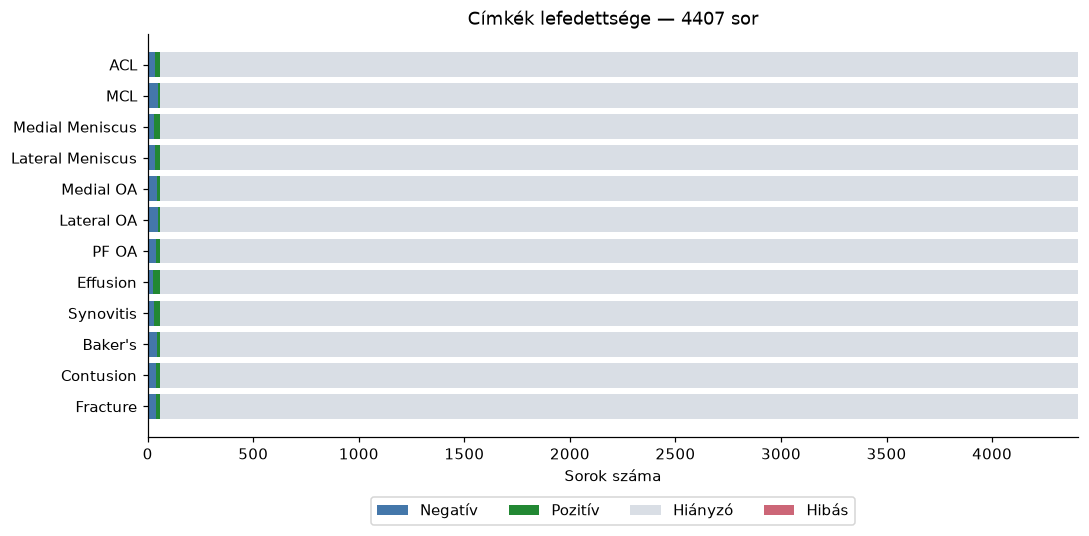

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
left = np.zeros(len(LABELS))
for col, color, title in [("negative", "#4477AA", "Negatív"), ("positive", "#228833", "Pozitív"),
                          ("missing", "#D9DEE5", "Hiányzó"), ("invalid", "#CC6677", "Hibás")]:
    ax.barh(LABELS, label_summary[col], left=left, color=color, label=title)
    left += label_summary[col].to_numpy()
ax.invert_yaxis()
ax.set(xlabel="Sorok száma", title=f"Címkék lefedettsége — {len(raw)} sor")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.13))
fig.tight_layout()
plt.show()


## 4. Azonosítók, duplikációk, ellentmondások

Az azonosítókat nem javítjuk automatikusan. Az üres vagy szélső szóközt tartalmazó UID-k külön listára kerülnek. A duplikált sorok száma minden érintett sort tartalmaz, az „extra sor” pedig az első példányon felüli ismétléseket. Azonos UID melletti eltérő leletet és egymásnak ellentmondó ismert címkéket is jelölünk.


In [5]:
uid_text = raw[UID]
uid_blank = uid_text.str.strip().eq("")
uid_whitespace = uid_text.ne(uid_text.str.strip())
uid_duplicate = uid_text.duplicated(keep=False) & ~uid_blank
inventory["uid_blank"] = uid_blank
inventory["uid_whitespace"] = uid_whitespace
inventory["uid_duplicate"] = uid_duplicate
check("blank_uid_rows", int(uid_blank.sum()), "0 kívánatos; ezek nem kapcsolhatók megbízhatóan sorozathoz.")
check("uid_whitespace_rows", int(uid_whitespace.sum()), "0 kívánatos; nincs automatikus UID-javítás.")
check("duplicate_uid_rows", int(uid_duplicate.sum()), "Minden érintett sor; ne dobd el őket vizsgálat nélkül.")
check("duplicate_uid_extra_rows", int(uid_text[~uid_blank].duplicated().sum()), "Az első példányokon felüli sorok.")
check("exact_duplicate_extra_rows", int(raw.duplicated().sum()), "Minden oszlop alapján azonos extra sorok.")
tables["uid_issues"] = inventory.loc[uid_blank | uid_whitespace | uid_duplicate,
                                    ["row_number", UID, "uid_blank", "uid_whitespace", "uid_duplicate"]].copy()

conflicts = []
for study_id, group in raw.loc[uid_duplicate].groupby(UID):
    conflicting_labels = [c for c in LABELS if labels.loc[group.index, c].dropna().nunique() > 1]
    conflicts.append({UID: study_id, "rows": len(group),
                      "different_reports": group.Report.nunique() > 1,
                      "conflicting_labels": "; ".join(conflicting_labels)})
tables["uid_conflicts"] = pd.DataFrame(conflicts, columns=[UID, "rows", "different_reports", "conflicting_labels"])
show(tables["uid_issues"])
show(tables["uid_conflicts"])


Empty DataFrame
Columns: [row_number, StudyInstanceUID, uid_blank, uid_whitespace, uid_duplicate]
Index: []
Empty DataFrame
Columns: [StudyInstanceUID, rows, different_reports, conflicting_labels]
Index: []


## 5. Leletek hossza, duplikációja és ellenőrzési jelzői

A `report_chars` az eredeti szöveg karakterhossza; a szóközök alapján számolt `report_words` nem LLM-tokenszám. Külön keresünk pontos szövegazonosságot és csak szóköz/sortörés/kisbetű különbséget mutató ismétlődést. Ezek önmagukban nem bizonyítanak betegazonosságot.

A rövidség, egy fejlécnél végződő szöveg és a csak helyettesítőből álló lelet **ellenőrzési jelző**, nem automatikus selejtezés. A fejlécminta néhány gyakori nyelvre terjed ki, nem ismeri fel az összes csonka leletet. Sem diagnózist, sem célcímkét nem állítunk elő kulcsszavakkal.


statistic  report_chars  report_words
    count        4407.0        4407.0
     mean        1097.9         147.5
      std         693.9          95.3
      min          52.0           8.0
      25%         587.5          74.5
      50%         977.0         129.0
      75%        1459.5         202.0
      95%        2452.7         330.0
      99%        3101.9         414.0
      max        4743.0         690.0


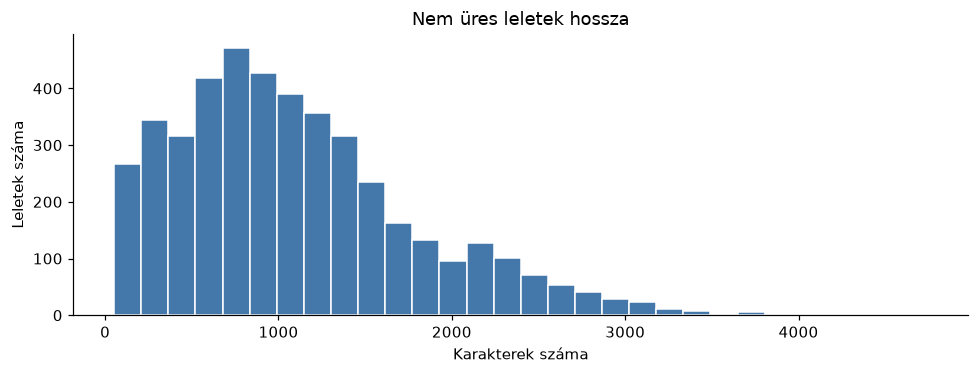

In [6]:
reports = raw["Report"]
stripped = reports.str.strip()
normalized = reports.str.replace(r"\s+", " ", regex=True).str.strip().str.casefold()
nonempty = stripped.ne("")
inventory["report_empty"] = ~nonempty
inventory["report_chars"] = reports.str.len()
inventory["report_words"] = reports.str.split().str.len()
inventory["report_hash"] = reports.map(lambda s: hashlib.sha256(s.encode("utf-8")).hexdigest())
inventory["report_duplicate_exact"] = reports.duplicated(keep=False) & nonempty
inventory["report_duplicate_normalized"] = normalized.duplicated(keep=False) & nonempty
inventory["report_short"] = nonempty & stripped.str.len().lt(SHORT_REPORT_CHARS)
inventory["report_long"] = stripped.str.len().gt(LONG_REPORT_CHARS)
heading_pattern = r"(?:findings|impression|bevindingen|conclusie|hallazgos|impresi[oó]n|resultados|conclusion|constatations|befund|beurteilung)\s*:\s*$"
inventory["report_ends_with_heading"] = stripped.str.contains(heading_pattern, case=False, regex=True, na=False)
inventory["report_placeholder_only"] = stripped.str.fullmatch(
    r"(?i)(?:n/?a|nan|null|none|unknown|\[.*?\]|[-?.]+)", na=False)
inventory["report_encoding_issue"] = reports.str.contains("\ufffd", regex=False)

report_lengths = inventory.loc[nonempty, ["report_chars", "report_words"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).rename_axis("statistic").reset_index()
tables["report_lengths"] = report_lengths
show(report_lengths.round(1))
report_flag_cols = ["report_empty", "report_short", "report_long", "report_ends_with_heading",
                    "report_placeholder_only", "report_encoding_issue", "report_duplicate_exact",
                    "report_duplicate_normalized"]
for col in report_flag_cols:
    check(col, int(inventory[col].sum()), "Heurisztikus leletellenőrzés; nincs automatikus törlés vagy címkézés.")

duplicate_rows = inventory.report_duplicate_exact | inventory.report_duplicate_normalized
tables["duplicate_reports"] = inventory.loc[duplicate_rows,
    ["row_number", UID, "report_hash", "report_duplicate_exact", "report_duplicate_normalized"]].copy()

fig, ax = plt.subplots(figsize=(9, 3.5))
if nonempty.any():
    ax.hist(inventory.loc[nonempty, "report_chars"], bins=min(30, max(3, int(np.sqrt(nonempty.sum())))), color="#4477AA", edgecolor="white")
else:
    ax.text(0.5, 0.5, "Nincs nem üres lelet", transform=ax.transAxes, ha="center")
ax.set(xlabel="Karakterek száma", ylabel="Leletek száma", title="Nem üres leletek hossza")
fig.tight_layout()
plt.show()


## 6. Opcionális nyelvfelismerés

A `langdetect` lokálisan fut. Azonos szövegre csak egyszer hívjuk; a seed rögzített. A score nem annak bizonyított valószínűsége, hogy a nyelv helyes. A rövid, kevert nyelvű vagy szokatlan orvosi szövegeket kézzel ellenőrizd. A nyelvfelismeréshez nem fordítjuk és nem küldjük el a leletet.

Ha a csomag nincs telepítve, nincs kitalált nyelv vagy nullának álcázott eredmény: `not_run` és hiányzó score szerepel. Telepítés után ezt és az ezt követő cellákat futtasd újra.


In [7]:
language_available = False
if RUN_LANGUAGE_DETECTION:
    try:
        from langdetect import detect_langs, DetectorFactory
        from langdetect.lang_detect_exception import LangDetectException
        DetectorFactory.seed = RANDOM_SEED
        language_available = True
    except ImportError:
        print("Nyelvfelismerés kihagyva: a langdetect nincs telepítve. %pip install langdetect")
else:
    print("Nyelvfelismerés kikapcsolva.")

def detect_report_language(text):
    if not text.strip():
        return ("empty", np.nan)
    if not language_available:
        return ("not_run", np.nan)
    try:
        result = detect_langs(text)
        return (result[0].lang, float(result[0].prob)) if result else ("unknown", np.nan)
    except LangDetectException:
        return ("unknown", np.nan)

language_cache = {text: detect_report_language(text) for text in stripped.unique()}
language_result = stripped.map(language_cache)
inventory["language"] = language_result.map(lambda x: x[0])
inventory["language_score"] = language_result.map(lambda x: x[1])
inventory["language_review"] = nonempty & (
    inventory.language.isin(["unknown", "not_run"]) |
    inventory.language_score.lt(LANGUAGE_SCORE_THRESHOLD) | inventory.report_short)
language_summary = inventory.groupby("language", dropna=False).agg(
    rows=("row_number", "size"), review_rows=("language_review", "sum"),
    median_chars=("report_chars", "median")).reset_index()
tables["language_summary"] = language_summary
show(language_summary)
tables["language_label_status"] = pd.crosstab(inventory.language, inventory.label_status).reset_index()
show(tables["language_label_status"])


language  rows  review_rows  median_chars
      bg   220            0         999.0
      de   262            0         807.0
      el   321            0         858.0
      en  1736            4        1270.0
      es   682           54         752.5
      fr    81            0        1560.0
      hr   406            3        1172.5
      nl   153            2         918.0
      tr   546            1         692.5
language  fully_labeled  unlabeled
      bg              3        217
      de              2        260
      el              3        318
      en             28       1708
      es             10        672
      fr              0         81
      hr              4        402
      nl              2        151
      tr              6        540


## 7. Sorozatleltár — csak ha megadod a train_series.csv-t

Egy sorozat több szeletből áll. A CSV alapján sorozatokat számolunk, nem képeket. Ellenőrizzük a kapcsolatokat, duplikált sorozatazonosítókat, a síkokat és a két bináris jellemzőt. A két jellemzőt külön változóként őrizzük meg.

**Részhalmaz esetén** a sorozattáblában található, de a mintából hiányzó study nem nevezhető árvának. Teljes train módban ugyanez tényleges kapcsolati eltérés. Minden megadott sorozatrekordot auditálunk, a lefedettséget csak az aktuális train vizsgálataira számoljuk. A sorozatok jellemzőeloszlása csak egyedi, hiánytalan kulcsokkal jelenik meg, így a duplikáció nem torzítja csendben az eredményt.


In [8]:
series = None
series_current = None
inventory["series_count"] = pd.Series(pd.NA, index=inventory.index, dtype="Int64")
if SERIES_PATH is None:
    print("Sorozatleltár kihagyva: SERIES_PATH = None. A sorozatszám ismeretlen, nem 0.")
else:
    series = read_csv_strict(SERIES_PATH)
    required_series = [UID, "SeriesInstanceUID", "Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"]
    missing = sorted(set(required_series) - set(series.columns))
    if missing:
        raise ValueError(f"Hiányzó sorozatoszlopok: {missing}")
    s_uid_blank = series[UID].str.strip().eq("")
    s_id_blank = series.SeriesInstanceUID.str.strip().eq("")
    s_ws = series[UID].ne(series[UID].str.strip()) | series.SeriesInstanceUID.ne(series.SeriesInstanceUID.str.strip())
    s_dup = series.SeriesInstanceUID.duplicated(keep=False) & ~s_id_blank
    check("series_blank_key_rows", int((s_uid_blank | s_id_blank).sum()), "0 kívánatos.")
    check("series_key_whitespace_rows", int(s_ws.sum()), "0 kívánatos; azonosítók nincsenek automatikusan javítva.")
    check("duplicate_series_uid_rows", int(s_dup.sum()), "Minden érintett sorozatrekord.")
    tables["series_key_issues"] = series.loc[s_uid_blank | s_id_blank | s_dup | s_ws].copy()
    valid_keys = ~(s_uid_blank | s_id_blank | s_ws)
    train_ids = set(raw.loc[~uid_blank & ~uid_whitespace, UID])
    outside = series.loc[valid_keys & ~series[UID].isin(train_ids)].copy()
    tables["series_outside_train"] = outside
    check("series_studies_outside_train", int(outside[UID].nunique()),
          "Árva study a teljes trainhez képest." if IS_FULL_TRAIN else "Mintán kívüli study; nem bizonyított árva rekord.")
    series_current = series.loc[valid_keys & series[UID].isin(train_ids)].copy()
    counts = series_current.groupby(UID).SeriesInstanceUID.nunique()
    inventory["series_count"] = inventory[UID].map(counts).fillna(0).astype("Int64")
    inventory.loc[uid_blank | uid_whitespace, "series_count"] = pd.NA
    tables["studies_without_series"] = inventory.loc[inventory.series_count.eq(0).fillna(False), ["row_number", UID]].copy()
    check("study_rows_without_series", len(tables["studies_without_series"]), "Nincs megfelelő rekord a megadott sorozat-CSV-ben; ez nem DICOM-letöltési ellenőrzés.")
    print("Sorozat-CSV rekordok:", len(series), "| aktuális study-k sorozatrekordjai:", len(series_current))
    show(counts.describe().rename("unique_series").rename_axis("statistic").reset_index())

    feature_issues = []
    for feature, allowed in [("Anatomical_Plane", {"Sagittal", "Coronal", "Axial"}),
                             ("Fluid_Sensitive", {"0", "1", "0.0", "1.0"}),
                             ("Fat_Suppression", {"0", "1", "0.0", "1.0"})]:
        values = series[feature].str.strip()
        bad = ~values.isin(allowed)
        check(f"invalid_{feature}_rows", int(bad.sum()), "Hiányzó vagy nem várt jellemző a teljes megadott sorozat-CSV-ben.")
        for idx in series.index[bad]:
            feature_issues.append({UID: series.at[idx, UID], "SeriesInstanceUID": series.at[idx, "SeriesInstanceUID"],
                                   "feature": feature, "raw_value": series.at[idx, feature]})
    tables["series_feature_issues"] = pd.DataFrame(feature_issues, columns=[UID, "SeriesInstanceUID", "feature", "raw_value"])
    if (s_dup | s_uid_blank | s_id_blank | s_ws).any():
        print("A kulcshibák rendezéséig nincs sík-/szekvenciaeloszlás. Az egyedi sorozatszámok diagnosztikai értékek.")
    else:
        feature_distribution = series_current.groupby(
            ["Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"], dropna=False).size().rename("series").reset_index()
        tables["series_features"] = feature_distribution
        show(feature_distribution)
        planes = pd.crosstab(series_current[UID], series_current.Anatomical_Plane)
        planes = planes.reindex(index=sorted(train_ids), columns=["Sagittal", "Coronal", "Axial"], fill_value=0)
        plane_coverage = planes.gt(0).rename_axis(UID).reset_index()
        plane_coverage["all_three_planes"] = plane_coverage[["Sagittal", "Coronal", "Axial"]].all(axis=1)
        tables["plane_coverage"] = plane_coverage
        show(plane_coverage.head(15))


Sorozat-CSV rekordok: 24371 | aktuális study-k sorozatrekordjai: 24371
statistic  unique_series
    count    4407.000000
     mean       5.530066
      std       1.393826
      min       3.000000
      25%       5.000000
      50%       5.000000
      75%       6.000000
      max      14.000000
Anatomical_Plane Fluid_Sensitive Fat_Suppression  series
           Axial               0               0    1179
           Axial               1               1    4719
         Coronal               0               0    3985
         Coronal               1               1    4624
        Sagittal               0               0    5197
        Sagittal               1               1    4667
                                                StudyInstanceUID  Sagittal  Coronal  Axial  all_three_planes
1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260      True     True   True              True
1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585      True     True   T

## 8. Opcionális helyi fájlleltár

Csak a sorozat-CSV-ben felsorolt, az aktuális trainhez kapcsolt mappákat járjuk be. A `*.dcm` fájlokat számoljuk és a 0 bájtos fájlokat jelezzük. Nincs DICOM-dekódolás vagy GPU-használat. Egy nem üres mappa **nem bizonyítja**, hogy a letöltés teljes vagy minden kép olvasható; ehhez később a teljes fájllista és DICOM-ellenőrzés kell.


In [9]:
if not CHECK_DICOM_FILES:
    print("Helyi fájlellenőrzés kikapcsolva.")
elif DICOM_ROOT is None or series_current is None:
    raise ValueError("Fájlellenőrzéshez DICOM_ROOT és SERIES_PATH is szükséges.")
elif not Path(DICOM_ROOT).is_dir():
    raise FileNotFoundError(f"Nincs ilyen DICOM-gyökérmappa: {DICOM_ROOT}")
else:
    disk_rows = []
    for study_id, series_id in series_current[[UID, "SeriesInstanceUID"]].drop_duplicates().itertuples(index=False, name=None):
        if not re.fullmatch(r"[0-9]+(?:\.[0-9]+)*", study_id) or not re.fullmatch(r"[0-9]+(?:\.[0-9]+)*", series_id):
            disk_rows.append({UID: study_id, "SeriesInstanceUID": series_id,
                              "status": "invalid_uid_path", "dcm_files": None, "zero_byte_files": None})
            continue
        folder = Path(DICOM_ROOT) / study_id / series_id
        files = list(folder.glob("*.dcm")) if folder.is_dir() else []
        files = [p for p in files if p.is_file()]
        disk_rows.append({UID: study_id, "SeriesInstanceUID": series_id,
                          "status": "missing_folder" if not folder.is_dir() else ("empty_folder" if not files else "files_present_unverified"),
                          "dcm_files": len(files), "zero_byte_files": sum(p.stat().st_size == 0 for p in files)})
    disk_inventory = pd.DataFrame(disk_rows, columns=[UID, "SeriesInstanceUID", "status", "dcm_files", "zero_byte_files"])
    tables["disk_inventory"] = disk_inventory
    show(disk_inventory.groupby("status").size().rename("series").reset_index())


                  status  series
files_present_unverified   24371


## 9. Összefoglaló és következő munkalista

Az alábbi tábla adatminőségi jelzőket tartalmaz. A `language_review` külön oszlop: a nyelvdetektor hiánya nem jelenti azt, hogy minden lelet hibás. Az LLM-re jelölt sorok listája előszűrés, nem jóváhagyás és nem végleges train/validation split. Csonka/üres szövegből ne állíts elő automatikusan negatív címkéket.


In [10]:
quality_cols = ["uid_blank", "uid_whitespace", "uid_duplicate"] + report_flag_cols
inventory["review_reasons"] = inventory.apply(
    lambda row: "; ".join([c for c in quality_cols if bool(row[c])] +
                           (["invalid_labels"] if row.invalid_labels > 0 else [])), axis=1)
inventory["needs_data_review"] = inventory.review_reasons.ne("")
inventory["report_preview"] = reports.str.replace(r"\s+", " ", regex=True).str.strip().str.slice(0, 160)
tables["review_queue"] = inventory.loc[inventory.needs_data_review].copy()
tables["study_inventory"] = inventory.copy()
tables["quality_checks"] = pd.DataFrame(checks)
summary = {
    "rows": len(raw),
    "unique_nonblank_study_ids": int(raw.loc[~uid_blank, UID].nunique()),
    "columns": len(raw.columns),
    "nonempty_reports": int(nonempty.sum()),
    "fully_labeled_rows": int(inventory.label_status.eq("fully_labeled").sum()),
    "partially_labeled_rows": int(inventory.label_status.eq("partially_labeled").sum()),
    "unlabeled_rows": int(inventory.label_status.eq("unlabeled").sum()),
    "rows_with_invalid_labels": int(inventory.invalid_labels.gt(0).sum()),
    "known_label_cells": int(valid_mask.to_numpy().sum()),
    "missing_label_cells": int(missing_mask.to_numpy().sum()),
    "invalid_label_cells": int(invalid_mask.to_numpy().sum()),
    "rows_for_data_review": int(inventory.needs_data_review.sum()),
    "language_detection_executed": language_available,
    "series_csv_analyzed": series is not None,
    "is_full_train": IS_FULL_TRAIN,
}
tables["summary"] = pd.DataFrame(summary.items(), columns=["metric", "value"])
show(tables["summary"])
print("\nAdatminőségi ellenőrzések:")
show(tables["quality_checks"])
print("\nEllenőrzendő leletek — legfeljebb 10:")
show(tables["review_queue"][["row_number", UID, "review_reasons", "report_preview"]], n=10)

candidate_mask = inventory.known_labels.lt(12) & ~inventory.needs_data_review & nonempty
tables["llm_candidates"] = inventory.loc[candidate_mask, ["row_number", UID, "report_hash", "language", "language_review", "known_labels"]].copy()
print(f"\nLLM-előszűrésen átment sorok: {candidate_mask.sum()} (a nyelvi ellenőrzés ettől külön feladat).")
print("A következő notebook előtt: adatminőségi hibák ellenőrzése, címkézési szabályok, elkülönített ellenőrző minta.")


                     metric value
                       rows  4407
  unique_nonblank_study_ids  4407
                    columns    14
           nonempty_reports  4407
         fully_labeled_rows    58
     partially_labeled_rows     0
             unlabeled_rows  4349
   rows_with_invalid_labels     0
          known_label_cells   696
        missing_label_cells 52188
        invalid_label_cells     0
       rows_for_data_review   219
language_detection_executed  True
        series_csv_analyzed  True
              is_full_train  True

Adatminőségi ellenőrzések:
                        check  count                                                                        interpretation
          invalid_label_cells      0                                0 kívánatos; nyers értékek az invalid_labels táblában.
               blank_uid_rows      0                           0 kívánatos; ezek nem kapcsolhatók megbízhatóan sorozathoz.
          uid_whitespace_rows      0                       

## 10. Kimenetek mentése

Minden futás új almappát hoz létre. A CSV-k UTF-8 BOM kódolásúak, így az ékezetek Excelben is könnyebben megnyithatók. UID-k kezeléséhez Python használata javasolt. A `study_inventory` egy soronkénti munkatábla, a nyers leletet és eredeti címkéket az eredeti CSV őrzi. Az ellenőrzési lista rövid szövegrészleteket tartalmaz.

A metaadatfájl rögzíti a bemenet SHA-256 hashét és a csomagverziókat. A notebook kimeneteiből is töröld a mintafutás eredményeit, ha másoknak üres sablonként szeretnéd továbbadni.


In [11]:
def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
run_dir = OUTPUT_ROOT / (TRAIN_PATH.stem + "_" + run_id)
run_dir.mkdir(parents=True, exist_ok=False)
for name, table in tables.items():
    table.to_csv(run_dir / f"{name}.csv", index=False, encoding="utf-8-sig")
metadata = {
    "created_utc": run_id, "train_path": str(TRAIN_PATH.resolve()),
    "train_sha256": file_sha256(TRAIN_PATH), "summary": summary,
    "series_path": str(Path(SERIES_PATH).resolve()) if SERIES_PATH is not None else None,
    "series_sha256": file_sha256(SERIES_PATH) if SERIES_PATH is not None else None,
    "versions": {"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__},
    "settings": {"seed": RANDOM_SEED, "short_chars": SHORT_REPORT_CHARS, "long_chars": LONG_REPORT_CHARS,
                 "language_score_threshold": LANGUAGE_SCORE_THRESHOLD, "check_dicom_files": CHECK_DICOM_FILES,
                 "missing_label_tokens": sorted(MISSING_LABEL_TOKENS)},
    "notes": ["Hiányzó és hibás címkék elkülönítve; nincs automatikus címkekitöltés.",
              "A nyelvi score nem kalibrált; a leletjelzők heurisztikusak.",
              "Nem üres DICOM-mappa nem bizonyít teljes vagy hibátlan letöltést."]
}
if language_available:
    from importlib.metadata import version
    metadata["versions"]["langdetect"] = version("langdetect")
(run_dir / "run_metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Elmentve: {len(tables)} CSV és run_metadata.json")
print(run_dir.resolve())


Elmentve: 22 CSV és run_metadata.json
F:\Kaggle\html_export_EN\train_20260917T051755_836646Z


## Források és értelmezés

- Sémaminták: a csatolt `train_sample.csv` és `train_series_sample.csv`; a teljes `train.csv` nem állt rendelkezésre a készítéskor.
- [Kaggle adatleírás](https://www.kaggle.com/competitions/rsna-knee-abnormality-detection/data): oszlopok és sorozatstruktúra.
- [pandas read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html): szöveges beolvasás és hiányértékek kezelése.
- [langdetect](https://github.com/Mimino666/langdetect): opcionális nyelvfelismerés, rögzített seed.

A teljesen címkézetlen mintán nem számítható pozitív gyakoriság, címkekorreláció vagy osztályegyensúly. A későbbi teljes leltár ismert címkéinek gyakorisága sem feltétlenül reprezentálja a teljes tanító- vagy tesztpopulációt.


## 11. English HTML report and ZIP

This cell converts the saved inventory CSVs into an English overview page and separate searchable, sortable tables. All titles, descriptions, controls, warnings and notebook-authored quality check explanations are displayed in English. Clinical report text, identifiers and downloadable source CSVs retain their original values.

The output is `html_report_en/index.html` and `inventory_report_en.zip` inside the current run directory. Download and extract the entire ZIP, then open `index.html` in your browser. The report works offline; keep all extracted files together.

If you have already configured your Kaggle notebook for the full dataset, copy only the final code cell below into it, after CSV export. Leave `HTML_SOURCE_DIR = None` to use the current `run_dir`, or set it to a previous output directory to regenerate the HTML without rerunning the inventory. Rerunning this cell refreshes the English report for that directory.


In [12]:
# English HTML report from the CSVs saved above; no extra packages or internet required.
from pathlib import Path
from html import escape
import json
import shutil
import zipfile
import pandas as pd

# Leave as None to use run_dir from the current notebook session.
# Or specify an existing CSV output directory to export without rerunning the analysis.
HTML_SOURCE_DIR = None
html_source = Path(HTML_SOURCE_DIR) if HTML_SOURCE_DIR is not None else Path(run_dir)
csv_paths = sorted(html_source.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No CSV files found in: {html_source.resolve()}")

html_dir = html_source / "html_report_en"
html_dir.mkdir(exist_ok=True)

REPORT_TITLES = {
    "summary": ("Summary", "Key metrics and analyses performed in this run."),
    "review_queue": ("Review queue", "Data quality flags and short report excerpts for manual review."),
    "quality_checks": ("Quality checks", "Counts and interpretation for each quality check."),
    "label_summary": ("Label coverage", "Positive, negative, missing and invalid values for each label."),
    "label_status": ("Labeling status", "Fully labeled, partially labeled and unlabeled rows."),
    "study_inventory": ("Study inventory", "Complete study inventory: identifiers, label counts and report characteristics."),
    "llm_candidates": ("LLM candidates", "Rows passing the initial screening; not a finalized training or validation set."),
    "language_summary": ("Report languages", "Language detection results; not_run means detection was not performed."),
    "language_label_status": ("Language and labeling status", "Labeling status distribution by detected language."),
    "report_lengths": ("Report lengths", "Character and word counts; these are not LLM token counts."),
    "duplicate_reports": ("Duplicate reports", "Exact and normalized text duplicates."),
    "invalid_labels": ("Invalid label values", "Raw values that cannot be classified as 0, 1 or missing."),
    "uid_issues": ("Study identifier issues", "Missing, whitespace-containing or duplicate study identifiers."),
    "uid_conflicts": ("Conflicts within study identifiers", "Different reports or conflicting labels associated with the same study UID."),
    "schema": ("CSV schema", "Column names, data types and empty cells."),
    "series_features": ("Series characteristics", "Joint distribution of anatomical plane, fluid sensitivity and fat suppression."),
    "plane_coverage": ("Anatomical plane coverage", "Anatomical planes available for each study."),
    "series_key_issues": ("Series identifier issues", "Invalid and duplicate keys in the series table."),
    "series_feature_issues": ("Series feature issues", "Missing or unexpected series feature values."),
    "series_outside_train": ("Series outside the supplied train table", "For a subset, absence from the train table does not establish an orphan record."),
    "studies_without_series": ("Studies without matching series", "Studies with no matching record in the supplied series CSV."),
    "disk_inventory": ("Local DICOM files", "File counts; presence alone does not establish DICOM readability or completeness."),
}
PRIORITY = ["summary", "review_queue", "quality_checks", "label_summary", "label_status",
            "study_inventory", "series_features", "plane_coverage", "language_summary", "llm_candidates"]
csv_paths.sort(key=lambda p: (PRIORITY.index(p.stem) if p.stem in PRIORITY else len(PRIORITY), p.stem))

css = """
:root{color-scheme:light;--ink:#172b40;--muted:#566777;--line:#d9e2e9;--blue:#16627c;--bg:#f3f6f8}
*{box-sizing:border-box}body{margin:0;background:var(--bg);color:var(--ink);font:15px/1.55 system-ui,-apple-system,Segoe UI,sans-serif}
main{max-width:1440px;margin:auto;padding:32px 28px 56px}a{color:var(--blue);text-underline-offset:3px}h1{font-size:32px;line-height:1.2;margin:8px 0 14px;letter-spacing:-.6px}h2{font-size:20px;margin:0 0 12px}
.eyebrow{font-size:12px;letter-spacing:1.6px;font-weight:700;color:var(--blue)}.muted{color:var(--muted)}.context{font-size:13px;overflow-wrap:anywhere}.cards{display:grid;grid-template-columns:repeat(4,minmax(0,1fr));gap:14px;margin:24px 0}
.card,.panel{background:white;border:1px solid var(--line);border-radius:12px;padding:20px}.card strong{display:block;font-size:31px;font-variant-numeric:tabular-nums}.card span{font-size:13px;color:var(--muted)}.panel{margin:20px 0}
.notice{padding:14px 18px;border-left:4px solid #bb7c12;background:#fff6e5;border-radius:5px;margin:18px 0}.links{display:flex;flex-wrap:wrap;gap:12px;margin:18px 0}
.button,button,select{font:inherit;border:1px solid var(--line);background:white;border-radius:6px;padding:8px 12px;color:var(--ink)}button,.button{cursor:pointer}.button{text-decoration:none}button:hover,.button:hover{background:#eaf3f6}button:disabled{opacity:.45;cursor:default}
input[type=search]{font:inherit;min-width:200px;flex:1;border:1px solid #a9bac8;border-radius:6px;padding:10px 12px;background:white;color:var(--ink)}input:focus,button:focus-visible,a:focus-visible{outline:3px solid #6db7d0;outline-offset:2px}
.toolbar{display:flex;flex-wrap:wrap;align-items:center;gap:12px;margin:18px 0}.scroll{overflow:auto;max-height:72vh;border:1px solid var(--line);border-radius:8px;background:white}table{border-collapse:separate;border-spacing:0;width:100%;font-size:13px}th,td{text-align:left;border-bottom:1px solid #e7edf1;padding:10px 12px;vertical-align:top}thead th{position:sticky;top:0;z-index:1;background:#edf3f6;white-space:nowrap}
th button{padding:3px 0;border:0;border-radius:0;background:transparent;font-weight:650;text-align:left;width:100%}tbody tr:nth-child(even){background:#f8fafb}tbody tr:hover{background:#eef6f9}.cell{min-width:70px;max-width:440px;max-height:7rem;overflow:auto;overflow-wrap:anywhere;white-space:pre-wrap}.expanded .cell{max-height:none}.empty{color:#778894}#status{font-variant-numeric:tabular-nums}.pager{display:flex;align-items:center;gap:12px;justify-content:flex-end;margin-top:14px}.catalog td:first-child{min-width:200px}.catalog td{padding:15px 12px}.count{white-space:nowrap;font-variant-numeric:tabular-nums}.chart-row{display:grid;grid-template-columns:150px 1fr 95px;gap:14px;align-items:center;margin:10px 0;font-size:13px}.bar{display:flex;background:#eef2f5;height:17px;border-radius:4px;overflow:hidden}.legend{display:flex;flex-wrap:wrap;gap:18px;font-size:13px;color:var(--muted);margin-top:16px}.legend i{display:inline-block;width:11px;height:11px;border-radius:2px;margin-right:5px}.hint{font-size:13px;color:var(--muted)}footer{margin-top:28px;font-size:12px;color:var(--muted)}noscript{display:block;background:#fff6e5;padding:15px}
@media(max-width:700px){main{padding:22px 14px}.cards{grid-template-columns:repeat(2,minmax(0,1fr))}h1{font-size:26px}.chart-row{grid-template-columns:105px 1fr 65px;gap:8px}.card{padding:14px}.catalog .description{display:none}}
"""

def html_shell(title, content, scripts=""):
    return ('<!doctype html><html lang="en"><head><meta charset="utf-8">'
            '<meta name="viewport" content="width=device-width, initial-scale=1">'
            f'<title>{escape(title)} · Knee MRI</title><style>{css}</style></head>'
            f'<body><main>{content}<footer>Knee MRI · Data inventory · Offline report</footer>'
            f'</main>{scripts}</body></html>')

table_js = r"""
<script>
(() => {
  const data=JSON.parse(document.getElementById('table-data').textContent);
  const headers=data.columns, records=data.rows;
  const tbody=document.querySelector('#grid tbody'), head=document.querySelector('#grid thead tr');
  const query=document.getElementById('query'), size=document.getElementById('page-size');
  let page=0, order=-1, direction=1, filtered=records.map((_,i)=>i);
  const normalize=s=>String(s).normalize('NFD').replace(/[\u0300-\u036f]/g,'').toLowerCase();
  const searchTexts=records.map(row=>normalize(row.join(' ')));
  const numbers=headers.map((name,j)=>!/(?:uid|hash)/i.test(name) && records.some(r=>r[j]!=='') && records.every(r=>r[j]==='' || /^[+-]?(?:\d+\.?\d*|\.\d+)(?:e[+-]?\d+)?$/i.test(r[j])));
  headers.forEach((name,j)=>{
    const th=document.createElement('th'), button=document.createElement('button');
    th.scope='col'; button.textContent=name+' ↕'; button.title='Sort by: '+name;
    button.addEventListener('click',()=>{direction=order===j?-direction:1; order=j; page=0; refresh();});
    th.appendChild(button);head.appendChild(th);
  });
  function refresh(){
    const terms=normalize(query.value).trim().split(/\s+/).filter(Boolean);
    filtered=records.map((_,i)=>i).filter(i=>terms.every(term=>searchTexts[i].includes(term)));
    if(order>=0) filtered.sort((a,b)=>{
      const av=records[a][order],bv=records[b][order];
      if(av===''||bv==='') return av===''?(bv===''?a-b:1):-1;
      const cmp=numbers[order]?Number(av)-Number(bv):av.localeCompare(bv,'en',{numeric:false});
      return cmp*direction || a-b;
    });
    [...head.children].forEach((th,j)=>{
      th.setAttribute('aria-sort',j===order?(direction===1?'ascending':'descending'):'none');
      th.firstChild.textContent=headers[j]+(j===order?(direction===1?' ↑':' ↓'):' ↕');
    });
    render();
  }
  function render(){
    const limit=Number(size.value), pages=Math.max(1,Math.ceil(filtered.length/limit));
    page=Math.max(0,Math.min(page,pages-1));tbody.replaceChildren();
    const fragment=document.createDocumentFragment();
    filtered.slice(page*limit,(page+1)*limit).forEach(i=>{
      const tr=document.createElement('tr');
      records[i].forEach(value=>{const td=document.createElement('td'),div=document.createElement('div');div.className='cell';div.textContent=value===''?'—':value;if(value==='')div.classList.add('empty');td.appendChild(div);tr.appendChild(td);});
      fragment.appendChild(tr);
    });
    if(!filtered.length){const tr=document.createElement('tr'),td=document.createElement('td');td.colSpan=Math.max(1,headers.length);td.textContent=records.length?'No matching rows.':'This table contains no data rows.';tr.appendChild(td);fragment.appendChild(tr);}
    tbody.appendChild(fragment);
    document.getElementById('status').textContent=filtered.length.toLocaleString('en')+' / '+records.length.toLocaleString('en')+' rows · page '+(page+1)+' / '+pages;
    document.getElementById('prev').disabled=page===0;document.getElementById('next').disabled=page>=pages-1;
  }
  let timer;query.addEventListener('input',()=>{clearTimeout(timer);timer=setTimeout(()=>{page=0;refresh();},120);});
  size.addEventListener('change',()=>{page=0;render();});
  document.getElementById('prev').addEventListener('click',()=>{page--;render();});
  document.getElementById('next').addEventListener('click',()=>{page++;render();});
  document.getElementById('expand').addEventListener('change',e=>document.getElementById('grid').classList.toggle('expanded',e.target.checked));
  refresh();
})();
</script>
"""

# Translate only explanations authored by this notebook, for HTML display.
# Source CSV downloads, identifiers and clinical reports remain unchanged.
QUALITY_EXPLANATIONS_EN = {'0 kívánatos; nyers értékek az invalid_labels táblában.': 'Expected: 0. Raw values are listed in the invalid_labels table.', '0 kívánatos; ezek nem kapcsolhatók megbízhatóan sorozathoz.': 'Expected: 0. These rows cannot be reliably linked to series.', '0 kívánatos; nincs automatikus UID-javítás.': 'Expected: 0. UIDs are not automatically corrected.', 'Minden érintett sor; ne dobd el őket vizsgálat nélkül.': 'Counts all affected rows; review them before removing any.', 'Az első példányokon felüli sorok.': 'Additional rows beyond the first occurrence of each identifier.', 'Minden oszlop alapján azonos extra sorok.': 'Additional rows that are identical across all columns.', 'Heurisztikus leletellenőrzés; nincs automatikus törlés vagy címkézés.': 'Heuristic report check; no automatic deletion or labeling.', '0 kívánatos.': 'Expected: 0.', '0 kívánatos; azonosítók nincsenek automatikusan javítva.': 'Expected: 0. Identifiers are not automatically corrected.', 'Minden érintett sorozatrekord.': 'Counts all affected series records.', 'Árva study a teljes trainhez képest.': 'Study with no matching record in the full training table.', 'Mintán kívüli study; nem bizonyított árva rekord.': 'Study outside the supplied sample; not a confirmed orphan record.', 'Nincs megfelelő rekord a megadott sorozat-CSV-ben; ez nem DICOM-letöltési ellenőrzés.': 'No matching record in the supplied series CSV; this does not check DICOM downloads.', 'Hiányzó vagy nem várt jellemző a teljes megadott sorozat-CSV-ben.': 'Missing or unexpected feature value across the entire supplied series CSV.'}

report_items = []
generated_files = []
loaded_reports = {}
for report_number, csv_path in enumerate(csv_paths, start=1):
    frame = pd.read_csv(csv_path, dtype=str, keep_default_na=False, encoding="utf-8-sig")
    loaded_reports[csv_path.stem] = frame
    title, description = REPORT_TITLES.get(csv_path.stem, (csv_path.stem, "An exported table from the current run."))
    page_name, csv_name = f"table_{report_number:02d}.html", f"data_{report_number:02d}.csv"
    shutil.copy2(csv_path, html_dir / csv_name)
    report_items.append({"stem": csv_path.stem, "title": title, "description": description,
                         "page": page_name, "csv": csv_name, "rows": len(frame), "columns": len(frame.columns)})
    # Escape script delimiters; the browser renders cell values using textContent.
    display_frame = frame.copy()
    if csv_path.stem == "quality_checks" and "interpretation" in display_frame:
        display_frame["interpretation"] = display_frame["interpretation"].map(
            lambda value: QUALITY_EXPLANATIONS_EN.get(value, value))
    payload = json.dumps({"columns": display_frame.columns.tolist(), "rows": display_frame.values.tolist()}, ensure_ascii=False)
    payload = payload.replace("&", "\\u0026").replace("<", "\\u003c").replace(">", "\\u003e").replace("\u2028", "\\u2028").replace("\u2029", "\\u2029")
    content = f"""
    <a href="index.html">← Back to overview</a>
    <h1>{escape(title)}</h1><p class="muted">{escape(description)}</p>
    <p class="context">Source: {escape(csv_path.name)} · {len(frame):,} rows · {len(frame.columns)} columns</p>
    <div class="toolbar"><input id="query" type="search" aria-label="Search table" placeholder="Search all columns…">
    <label>Rows per page <select id="page-size"><option>25</option><option selected>50</option><option>100</option><option>250</option></select></label>
    <a class="button" href="{csv_name}" download="{escape(csv_path.name, quote=True)}">Download CSV</a></div>
    <div class="toolbar"><label><input id="expand" type="checkbox"> Expand long text</label><span class="hint">Click a column heading to sort. Empty cell: —</span></div>
    <noscript>JavaScript is required for the searchable table. You can also download the CSV.</noscript>
    <div class="scroll"><table id="grid"><thead><tr></tr></thead><tbody></tbody></table></div>
    <div class="pager"><span id="status" role="status" aria-live="polite"></span><button id="prev">Previous</button><button id="next">Next</button></div>
    """
    scripts = '<script id="table-data" type="application/json">' + payload + '</script>' + table_js
    (html_dir / page_name).write_text(html_shell(title, content, scripts), encoding="utf-8")
    generated_files.extend([page_name, csv_name])

summary_frame = loaded_reports.get("summary")
metrics = dict(zip(summary_frame["metric"], summary_frame["value"])) if summary_frame is not None and {"metric", "value"} <= set(summary_frame) else {}
is_full = metrics.get("is_full_train", "").lower() == "true"
mode = "Full training table" if is_full else "Sample / subset or unspecified scope"
cards = "".join(f'<div class="card"><strong>{escape(metrics.get(key, "—"))}</strong><span>{label}</span></div>' for key, label in [
    ("rows", "Rows in the train table"), ("unique_nonblank_study_ids", "Unique nonempty study UIDs"),
    ("known_label_cells", "Known label values"), ("rows_for_data_review", "Rows flagged for data review")])
language_notice = '<p class="notice">Language detection was not performed in this run. The value not_run is a processing status, not a language or a report error.</p>' if metrics.get("language_detection_executed", "").lower() == "false" else ""
if metrics.get("known_label_cells") == "0":
    language_notice += '<p class="notice">No known labels are available, so positive label prevalence cannot be calculated. A missing label is not a negative label.</p>'

chart = ""
lf = loaded_reports.get("label_summary")
if lf is not None and {"label", "positive", "negative", "missing", "invalid"} <= set(lf):
    chart_rows = []
    colors = {"positive": "#22885f", "negative": "#3979a5", "missing": "#d8e1e8", "invalid": "#be5162"}
    for _, row in lf.iterrows():
        values = {key: float(row[key]) for key in colors}
        total = sum(values.values())
        segments = "".join(f'<span title="{key}: {value:g}" style="width:{100*value/total if total else 0:.5f}%;background:{colors[key]}"></span>' for key, value in values.items())
        known = values["positive"] + values["negative"]
        chart_rows.append(f'<div class="chart-row"><span>{escape(row["label"])}</span><div class="bar">{segments}</div><span>{known:g}/{total:g} known</span></div>')
    chart = '<section class="panel"><h2>Label coverage</h2>' + ''.join(chart_rows) + '<div class="legend">' + ''.join(
        f'<span><i style="background:{colors[key]}"></i>{label}</span>' for key,label in [("positive","Positive"),("negative","Negative"),("missing","Missing"),("invalid","Invalid")]) + '</div></section>'

item_by_stem = {item["stem"]: item for item in report_items}
quicklinks = ''.join(f'<a class="button" href="{item_by_stem[key]["page"]}">{escape(item_by_stem[key]["title"])}</a>' for key in ["review_queue","study_inventory","series_features"] if key in item_by_stem)
catalog = ''.join(f'<tr><td><a href="{item["page"]}">{escape(item["title"])}</a><div class="hint">{escape(item["stem"])}.csv</div></td><td class="description">{escape(item["description"])}</td><td class="count">{item["rows"]:,}</td><td class="count">{item["columns"]}</td></tr>' for item in report_items)
index_content = f"""
<div class="eyebrow">KNEE MRI / DATA INVENTORY</div><h1>Dataset overview</h1>
<p class="context muted">{escape(mode)} · Run: {escape(html_source.name)}</p>
<div class="cards">{cards}</div>{language_notice}<div class="links">{quicklinks}</div>{chart}
<section class="panel"><h2>Reports</h2><p class="hint">Every table supports search, sorting and pagination. Empty issue tables are included.</p>
<div class="toolbar"><input id="catalog-search" type="search" aria-label="Find a report" placeholder="Find a report by name or description…"></div>
<div style="overflow:auto"><table class="catalog"><thead><tr><th>Report</th><th class="description">What does it show?</th><th>Rows</th><th>Columns</th></tr></thead><tbody>{catalog}</tbody></table></div></section>
<p class="hint">Study UIDs are preserved as complete text strings. A study missing from a subset is not a confirmed orphan record. Data quality flags indicate items to review. Original clinical report text is kept in its source language.</p>
"""
index_script = """<script>document.getElementById('catalog-search').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('.catalog tbody tr').forEach(row=>row.hidden=!row.textContent.toLowerCase().includes(q));});</script>"""
(html_dir / "index.html").write_text(html_shell("Dataset overview", index_content, index_script), encoding="utf-8")
generated_files.insert(0, "index.html")
(html_dir / "README.txt").write_text("Extract the entire ZIP, then open index.html in a browser.\nKeep all linked pages and CSVs alongside index.html. No server or internet connection is required.\nThe files are a snapshot of this run. Clinical report text and downloadable source CSVs are preserved; notebook-authored quality check explanations are displayed in English.\n", encoding="utf-8")
generated_files.append("README.txt")
archive_path = html_source / "inventory_report_en.zip"
with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for name in generated_files:
        archive.write(html_dir / name, arcname=name)

print(f"English HTML report: {(html_dir / 'index.html').resolve()}")
print(f"Downloadable ZIP: {archive_path.resolve()}")
print(f"{len(report_items)} complete tables with search and sorting. All rows are included.")
print("Download and extract the ZIP, then open index.html in your browser.")
try:
    from IPython.display import display, FileLink
except ImportError:
    pass
else:
    # Use the relative Jupyter link or the notebook output file list.
    try:
        display(FileLink(str(archive_path.resolve().relative_to(Path.cwd().resolve()))))
    except ValueError:
        pass


English HTML report: F:\Kaggle\html_export_EN\train_20260917T051755_836646Z\html_report_en\index.html
Downloadable ZIP: F:\Kaggle\html_export_EN\train_20260917T051755_836646Z\inventory_report_en.zip
22 complete tables with search and sorting. All rows are included.
Download and extract the ZIP, then open index.html in your browser.
